# Phase 3: Baseline Modeling — Healthcare Triage Classification (MM26ML03)

**Author / Owner:** Shrijay Sinha (Modeling Owner)  
**Objective:** Establish non-cost-sensitive baseline benchmarks on the preprocessed dataset (`data/processed/train_processed.csv`) using a 5-Fold Stratified Cross-Validation scheme.

### Progression:
1. **Linear Benchmark:** Logistic Regression (Multinomial)
2. **Bagged Trees Benchmark:** Random Forest Classifier
3. **Boosted Trees Benchmark:** XGBoost Classifier

All models are evaluated via the shared evaluation harness (`src/evaluate.py` & `src/cost_matrix.py`) to record baseline Accuracy, Macro-F1, Weighted-F1, per-class metrics, Confusion Matrices, and Total Misclassification Cost.

In [1]:
import os
import sys
from pathlib import Path

# Add repo root to path so src modules import reliably
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from src.cost_matrix import CLASSES, COST_MATRIX, total_cost
from src.evaluate import detailed_metrics, print_report
from src.train import load_data, cross_validate_model, format_per_class_f1

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

## 1. Load Preprocessed Data
We load `data/processed/train_processed.csv` generated in Phase 2.

In [2]:
train_path = ROOT_DIR / "data" / "processed" / "train_processed.csv"
X, y = load_data(str(train_path))

print(f"Dataset Shape: X = {X.shape}, y = {y.shape}")
print(f"Features: {X.columns.tolist()[:8]} ... ({len(X.columns)} total features)")
print("\nTarget Class Distribution:")
target_dist = pd.Series(y).value_counts()
target_pct = pd.Series(y).value_counts(normalize=True) * 100
dist_df = pd.DataFrame({"Count": target_dist, "Percentage (%)": target_pct.round(2)})
dist_df

Dataset Shape: X = (664, 53), y = (664,)
Features: ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain_score', 'gcs_eye'] ... (53 total features)

Target Class Distribution:


,Count,Percentage (%)
YELLOW,284,42.77
GREEN,176,26.51
RED,135,20.33
BLACK,69,10.39


## 2. Clinical Cost Matrix
The PRD defines an asymmetric cost matrix where missing severe triage cases incurs high penalties:
- Actual **RED** classified as **GREEN** = Cost 10 (most critical under-triage)
- Actual **RED** classified as **YELLOW** or **BLACK** = Cost 5
- Actual **YELLOW** classified as **GREEN** = Cost 3

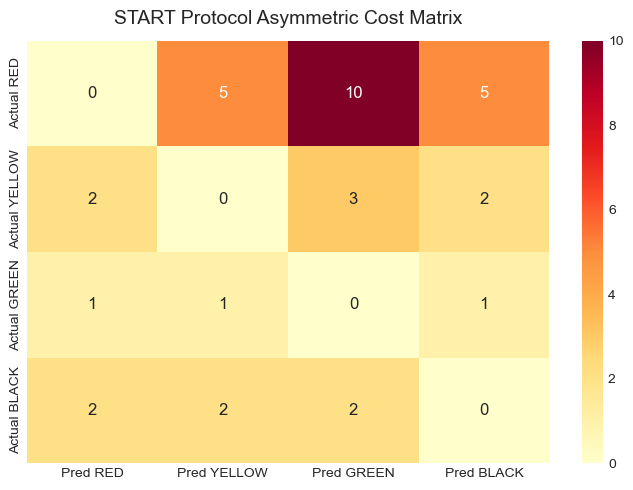

In [3]:
cost_df = pd.DataFrame(
    COST_MATRIX,
    index=[f"Actual {c}" for c in CLASSES],
    columns=[f"Pred {c}" for c in CLASSES]
)

plt.figure(figsize=(7, 5))
sns.heatmap(cost_df, annot=True, cmap="YlOrRd", fmt="d", cbar=True, annot_kws={"size": 12})
plt.title("START Protocol Asymmetric Cost Matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## 3. Baseline Model 1: Logistic Regression
Standard linear benchmark without cost sensitivity, fitted with L2 regularization (`max_iter=1000`).

In [4]:
lr_res = cross_validate_model(
    model_factory=lambda: LogisticRegression(max_iter=1000, random_state=42),
    X=X,
    y=y,
    cv=5,
    random_state=42,
    model_name="Logistic Regression Baseline"
)


Running 5-Fold Stratified CV for: Logistic Regression Baseline
  Fold 1 - Acc: 0.8571 | Macro-F1: 0.8715 | Weighted-F1: 0.8580 | Cost: 54
  Fold 2 - Acc: 0.8722 | Macro-F1: 0.8815 | Weighted-F1: 0.8724 | Cost: 57
  Fold 3 - Acc: 0.9098 | Macro-F1: 0.9211 | Weighted-F1: 0.9100 | Cost: 28


  Fold 4 - Acc: 0.9173 | Macro-F1: 0.9250 | Weighted-F1: 0.9170 | Cost: 28
  Fold 5 - Acc: 0.8561 | Macro-F1: 0.8803 | Weighted-F1: 0.8560 | Cost: 59

--- OOF Aggregate Results for Logistic Regression Baseline ---
Accuracy: 0.8825
Macro-F1: 0.8960
Weighted-F1: 0.8827
Total Misclassification Cost: 226

Per-class:
  RED: P=0.936 R=0.867 F1=0.900
  YELLOW: P=0.877 R=0.877 F1=0.877
  GREEN: P=0.832 R=0.869 F1=0.850
  BLACK: P=0.944 R=0.971 F1=0.957

Confusion Matrix:
[[117  12   2   4]
 [  6 249  29   0]
 [  0  23 153   0]
 [  2   0   0  67]]
CV Macro-F1 (mean +/- std): 0.8959 +/- 0.0225
CV Weighted-F1 (mean +/- std): 0.8827 +/- 0.0259
CV Total Cost (sum = 226, fold mean +/- std = 45.2 +/- 14.1)


## 4. Baseline Model 2: Random Forest Classifier
Ensemble of 200 decision trees to capture non-linear interactions across clinical features natively.

In [5]:
rf_res = cross_validate_model(
    model_factory=lambda: RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    X=X,
    y=y,
    cv=5,
    random_state=42,
    model_name="Random Forest Baseline"
)


Running 5-Fold Stratified CV for: Random Forest Baseline


  Fold 1 - Acc: 0.8346 | Macro-F1: 0.8588 | Weighted-F1: 0.8341 | Cost: 54


  Fold 2 - Acc: 0.8647 | Macro-F1: 0.8582 | Weighted-F1: 0.8635 | Cost: 59


  Fold 3 - Acc: 0.8722 | Macro-F1: 0.8795 | Weighted-F1: 0.8724 | Cost: 44


  Fold 4 - Acc: 0.8797 | Macro-F1: 0.8836 | Weighted-F1: 0.8783 | Cost: 50


  Fold 5 - Acc: 0.8939 | Macro-F1: 0.9153 | Weighted-F1: 0.8948 | Cost: 46

--- OOF Aggregate Results for Random Forest Baseline ---
Accuracy: 0.8690
Macro-F1: 0.8793
Weighted-F1: 0.8688
Total Misclassification Cost: 253

Per-class:
  RED: P=0.932 R=0.807 F1=0.865
  YELLOW: P=0.846 R=0.887 F1=0.866
  GREEN: P=0.847 R=0.852 F1=0.850
  BLACK: P=0.917 R=0.957 F1=0.936

Confusion Matrix:
[[109  20   0   6]
 [  5 252  27   0]
 [  0  26 150   0]
 [  3   0   0  66]]
CV Macro-F1 (mean +/- std): 0.8791 +/- 0.0209
CV Weighted-F1 (mean +/- std): 0.8686 +/- 0.0200
CV Total Cost (sum = 253, fold mean +/- std = 50.6 +/- 5.4)


## 5. Baseline Model 3: XGBoost Classifier
Gradient-boosted decision trees (`n_estimators=200`, `learning_rate=0.05`, `max_depth=4`).

In [6]:
xgb_res = cross_validate_model(
    model_factory=lambda: XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1
    ),
    X=X,
    y=y,
    cv=5,
    random_state=42,
    model_name="XGBoost Baseline"
)


Running 5-Fold Stratified CV for: XGBoost Baseline


  Fold 1 - Acc: 0.8722 | Macro-F1: 0.8906 | Weighted-F1: 0.8721 | Cost: 42


  Fold 2 - Acc: 0.8872 | Macro-F1: 0.8969 | Weighted-F1: 0.8878 | Cost: 45


  Fold 3 - Acc: 0.8571 | Macro-F1: 0.8686 | Weighted-F1: 0.8577 | Cost: 50


  Fold 4 - Acc: 0.8722 | Macro-F1: 0.8732 | Weighted-F1: 0.8716 | Cost: 46


  Fold 5 - Acc: 0.8939 | Macro-F1: 0.9137 | Weighted-F1: 0.8941 | Cost: 45

--- OOF Aggregate Results for XGBoost Baseline ---
Accuracy: 0.8765
Macro-F1: 0.8889
Weighted-F1: 0.8768
Total Misclassification Cost: 228

Per-class:
  RED: P=0.950 R=0.852 F1=0.898
  YELLOW: P=0.860 R=0.884 F1=0.872
  GREEN: P=0.833 R=0.852 F1=0.843
  BLACK: P=0.930 R=0.957 F1=0.943

Confusion Matrix:
[[115  15   0   5]
 [  3 251  30   0]
 [  0  26 150   0]
 [  3   0   0  66]]
CV Macro-F1 (mean +/- std): 0.8886 +/- 0.0164
CV Weighted-F1 (mean +/- std): 0.8767 +/- 0.0129
CV Total Cost (sum = 228, fold mean +/- std = 45.6 +/- 2.6)


## 6. Baseline Models Comparison & Clinical Cost Analysis

In [7]:
comparison_data = []
for res in [lr_res, rf_res, xgb_res]:
    m = res["oof_metrics"]
    comparison_data.append({
        "Model": res["model_name"],
        "Accuracy": round(m["accuracy"], 4),
        "Macro-F1": round(m["macro_f1"], 4),
        "Weighted-F1": round(m["weighted_f1"], 4),
        "RED F1": round(m["per_class"]["RED"]["f1"], 3),
        "YELLOW F1": round(m["per_class"]["YELLOW"]["f1"], 3),
        "GREEN F1": round(m["per_class"]["GREEN"]["f1"], 3),
        "BLACK F1": round(m["per_class"]["BLACK"]["f1"], 3),
        "Total Cost": m["total_cost"]
    })

comp_df = pd.DataFrame(comparison_data)
comp_df

,Model,Accuracy,Macro-F1,Weighted-F1,RED F1,YELLOW F1,GREEN F1,BLACK F1,Total Cost
0,Logistic Regression Baseline,0.8825,0.8960,0.8827,0.900,0.877,0.850,0.957,226
1,Random Forest Baseline,0.8690,0.8793,0.8688,0.865,0.866,0.850,0.936,253
2,XGBoost Baseline,0.8765,0.8889,0.8768,0.898,0.872,0.843,0.943,228


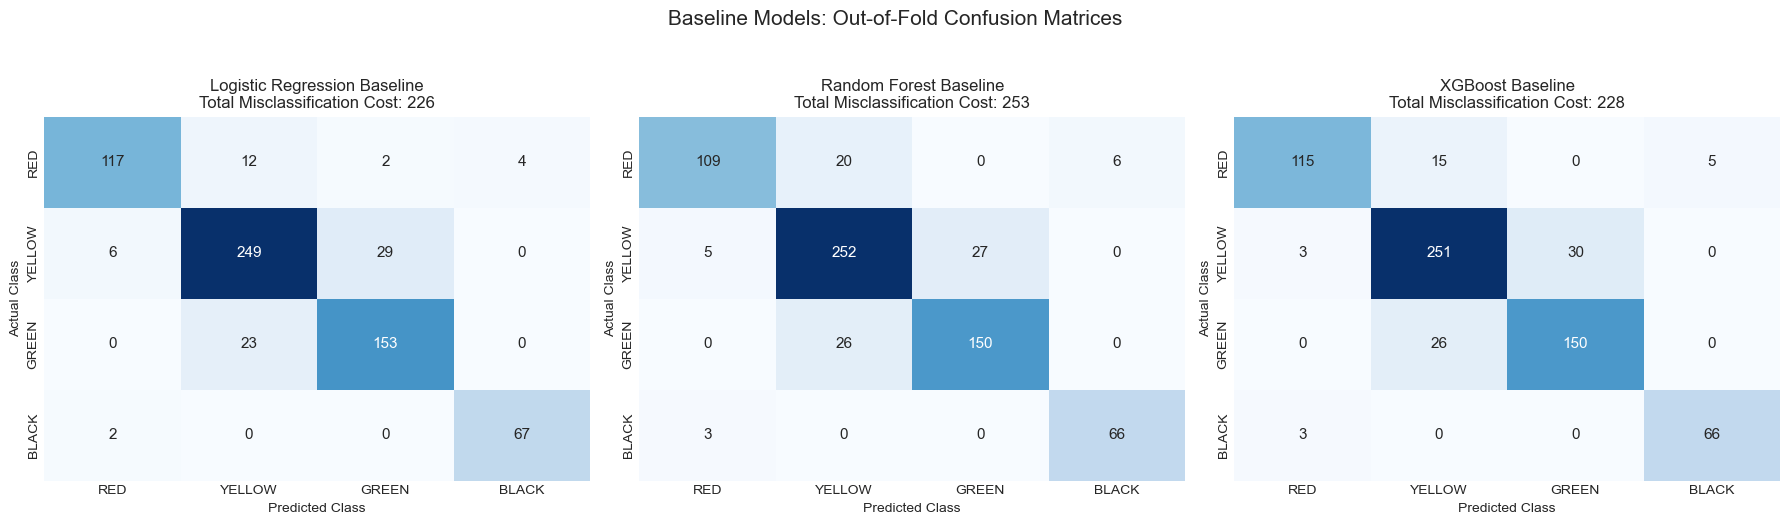

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, res in zip(axes, [lr_res, rf_res, xgb_res]):
    cm = res["oof_metrics"]["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={"size": 11})
    ax.set_title(f"{res['model_name']}\nTotal Misclassification Cost: {res['total_cost']}", fontsize=12)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

plt.suptitle("Baseline Models: Out-of-Fold Confusion Matrices", fontsize=15, y=1.04)
plt.tight_layout()
plt.show()

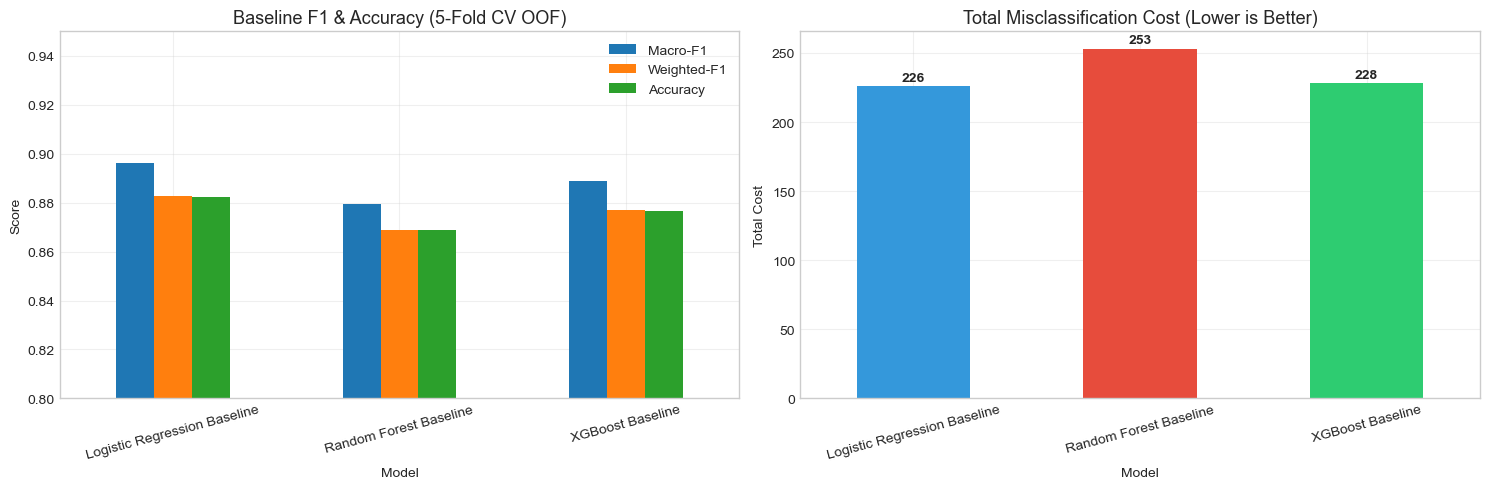

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Macro and Weighted F1
bar_df = comp_df.set_index("Model")[["Macro-F1", "Weighted-F1", "Accuracy"]]
bar_df.plot(kind="bar", ax=ax1, ylim=(0.80, 0.95), rot=15)
ax1.set_title("Baseline F1 & Accuracy (5-Fold CV OOF)", fontsize=13)
ax1.set_ylabel("Score")
ax1.grid(True, alpha=0.3)

# Total Misclassification Cost
cost_series = comp_df.set_index("Model")["Total Cost"]
cost_series.plot(kind="bar", ax=ax2, color=["#3498db", "#e74c3c", "#2ecc71"], rot=15)
ax2.set_title("Total Misclassification Cost (Lower is Better)", fontsize=13)
ax2.set_ylabel("Total Cost")
ax2.grid(True, alpha=0.3)
for i, v in enumerate(cost_series):
    ax2.text(i, v + 4, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 7. Key Findings & Motivation for Phase 4 (Cost-Sensitive Modeling)

### Summary of Baseline Results:
1. **Strong Baseline Predictive Power**:
   - Logistic Regression: **Accuracy = 88.25%**, **Macro-F1 = 0.8960**, **Total Cost = 226**
   - XGBoost: **Accuracy = 87.65%**, **Macro-F1 = 0.8889**, **Total Cost = 228**
   - Random Forest: **Accuracy = 86.90%**, **Macro-F1 = 0.8793**, **Total Cost = 253**

2. **The Clinical Problem with Standard Models**:
   - Notice that Random Forest achieved reasonable accuracy (86.9%), but had the **worst cost (253)** because it misclassified **26 actual RED patients** (20 as YELLOW, 6 as BLACK). Each RED misclassification carries a severe penalty of 5 to 10 points.
   - Logistic Regression achieved the lowest baseline cost (226), but still misclassified 2 RED patients as GREEN (cost = 20) and 12 RED patients as YELLOW (cost = 60).
   - XGBoost baseline misclassified 15 RED as YELLOW and 5 RED as BLACK.

3. **Phase 4 Action Plan**:
   Standard loss functions (cross-entropy, log-loss) assume symmetric cost. In **Phase 4: Cost-Sensitive Modeling Iterations**, we will introduce:
   - **Cost-sensitive class weighting** (`class_weight` / sample weights) prioritizing RED and YELLOW recall.
   - **Custom Cost-Sensitive Loss Functions** directly incorporating the asymmetric cost matrix into gradient boosting.
   - **Expected Cost Decoding (Bayes Decision Rule)**: Post-processing predicted class probabilities via $y^* = \arg\min_k \\sum_j P(Y=j|X) \\cdot C_{j,k}$ to explicitly minimize clinical cost.